Loading weights from /home/gantumur/Documents/DL/Lab123/models/best_model_weights.pth...
 - Loaded Layer 0 (Conv)
 - Loaded Layer 4 (Linear)
Weights loaded successfully!

Running evaluation on Test Set...
Test Set Accuracy: 97.70%


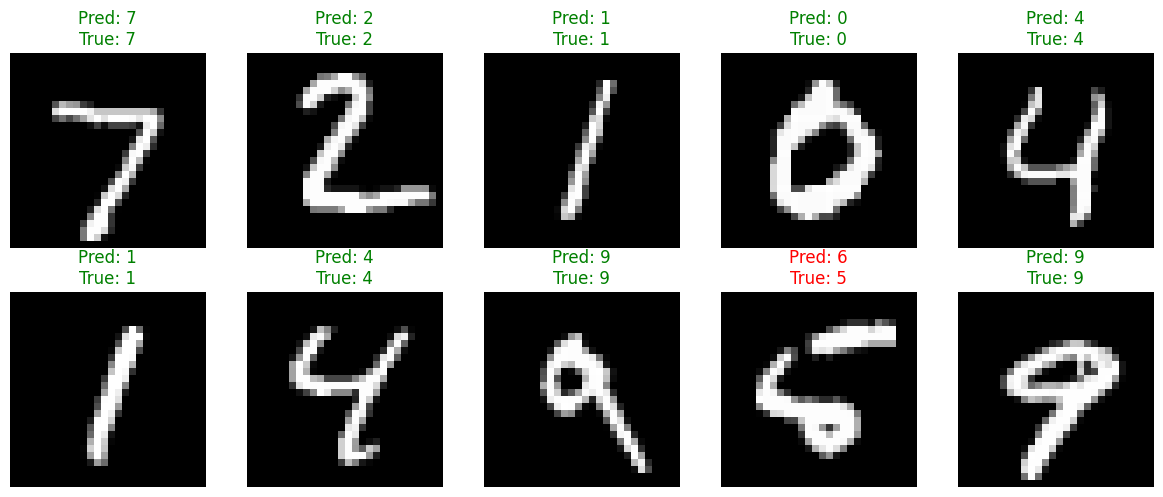

In [1]:
import torch
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
from model import *  


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

testset = datasets.MNIST(root="./data", train=False,
                         download=True, transform=transform)
testloader = DataLoader(testset, batch_size=128, shuffle=False)

model = ConvNET([
    ConvLayer(in_channels=1, out_channels=8, filter_dim=3,
              alpha=0.0), 
    ReLU(),
    MaxPool(pool_size=2, stride=2),
    Flatten(),
    Linear_Layer(input_dim=14*14*8, output_dim=10, alpha=0.0)
])



def load_weights(model, path):
    print(f"Loading weights from {path}...")
    try:
        checkpoint = torch.load(path, weights_only=False)

        for i, layer in enumerate(model.layers):

            if f'layer_{i}_filters' in checkpoint:
                layer.filters = cp.asarray(checkpoint[f'layer_{i}_filters'])
                layer.bias = cp.asarray(checkpoint[f'layer_{i}_bias'])
                print(f" - Loaded Layer {i} (Conv)")

            elif f'layer_{i}_theta' in checkpoint:
                layer.theta = cp.asarray(checkpoint[f'layer_{i}_theta'])
                layer.bias = cp.asarray(checkpoint[f'layer_{i}_bias'])
                print(f" - Loaded Layer {i} (Linear)")

        print("Weights loaded successfully!")

    except FileNotFoundError:
        print("Error: Model file not found. Please check the path.")
        exit()


load_weights(
    model, "/home/gantumur/Documents/DL/Lab123/models/best_model_weights.pth")

print("\nRunning evaluation on Test Set...")

correct = 0
total = 0

debug_images = []
debug_preds = []
debug_labels = []

for batch_idx, (data, target) in enumerate(testloader):

    x_batch = cp.asarray(data.numpy())
    y_batch = cp.asarray(target.numpy())

    logits = model.forward(x_batch)

    predictions = cp.argmax(logits, axis=1)

    correct += (predictions == y_batch).sum().item()
    total += y_batch.shape[0]

    if batch_idx == 0:

        debug_images = data.numpy()
        debug_preds = cp.asnumpy(predictions)
        debug_labels = target.numpy()

final_acc = 100 * correct / total
print(f"Test Set Accuracy: {final_acc:.2f}%")

fig = plt.figure(figsize=(12, 5))
for i in range(10):
    ax = fig.add_subplot(2, 5, i+1)

    img = debug_images[i].squeeze()

    ax.imshow(img, cmap='gray')

    pred = debug_preds[i]
    truth = debug_labels[i]

    color = 'green' if pred == truth else 'red'
    ax.set_title(f"Pred: {pred}\nTrue: {truth}", color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [2]:
import numpy as np


def count_parameters(model):
    total_params = 0
    print(f"{'Layer':<20} | {'Shape':<20} | {'Params':<10}")
    print("-" * 60)

    for i, layer in enumerate(model.layers):
        layer_params = 0
        name = str(type(layer).__name__)
        shape = ""
        if hasattr(layer, 'filters'):
            w = layer.filters.size
            b = layer.bias.size
            layer_params = w + b
            shape = str(layer.filters.shape)

        elif hasattr(layer, 'theta'):
            w = layer.theta.size
            b = layer.bias.size
            layer_params = w + b
            shape = str(layer.theta.shape)

        total_params += layer_params
        if layer_params > 0:
            print(f"{name:<20} | {shape:<20} | {layer_params:<10}")

    print("-" * 60)
    print(f"Total Trainable Params: {total_params}")


In [4]:
count_parameters(model)

Layer                | Shape                | Params    
------------------------------------------------------------
ConvLayer            | (8, 1, 3, 3)         | 80        
Linear_Layer         | (1568, 10)           | 15690     
------------------------------------------------------------
Total Trainable Params: 15770


Loading weights from /home/gantumur/Documents/DL/Lab123/models/bigger_best_model_weights.pth...
 - Loaded Layer 0 (Conv): Shape (32, 1, 3, 3)
 - Loaded Layer 3 (Conv): Shape (64, 32, 3, 3)
 - Loaded Layer 7 (Linear): Shape (1600, 128)
 - Loaded Layer 9 (Linear): Shape (128, 10)
Successfully loaded 4 layers.

Running evaluation on Test Set...
Test Set Accuracy: 98.56%


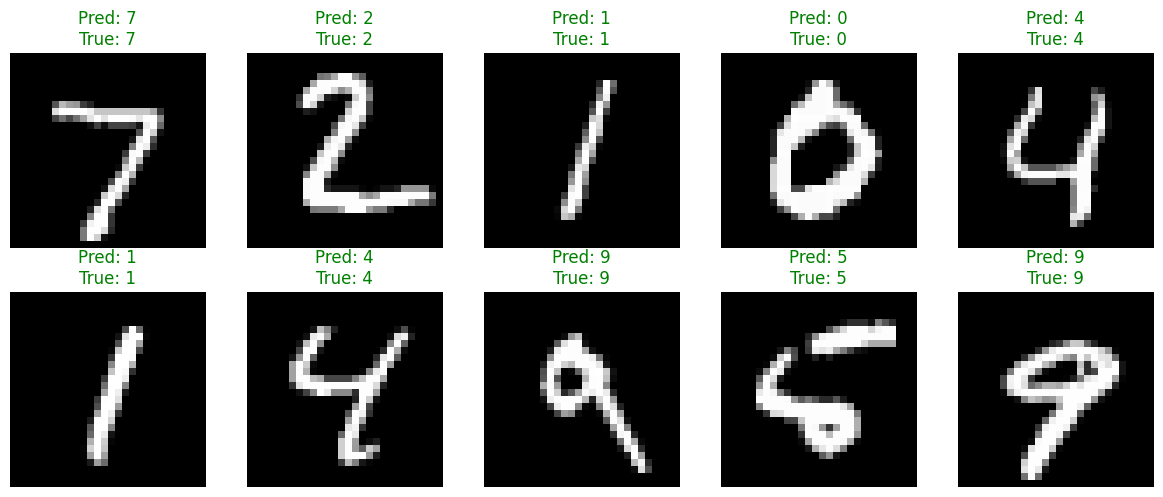

In [6]:
import torch
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
import os
from model import *

# 1. Setup Data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

testset = datasets.MNIST(root="./data", train=False,
                         download=True, transform=transform)
testloader = DataLoader(testset, batch_size=128, shuffle=False)

# 2. Define the Model (MUST match training architecture exactly)
model = ConvNET([
    # --- Block 1 ---
    # Input: (1, 28, 28) -> Conv: (32, 26, 26) -> Pool: (32, 13, 13)
    ConvLayer(in_channels=1, out_channels=32, filter_dim=3, pad=0, alpha=0.0),
    ReLU(),
    MaxPool(pool_size=2, stride=2),

    # --- Block 2 ---
    # Input: (32, 13, 13) -> Conv: (64, 11, 11) -> Pool: (64, 5, 5)
    ConvLayer(in_channels=32, out_channels=64, filter_dim=3, pad=0, alpha=0.0),
    ReLU(),
    MaxPool(pool_size=2, stride=2),

    # --- Classifier ---
    Flatten(),
    # 64 filters * 5 * 5 = 1600
    Linear_Layer(input_dim=1600, output_dim=128, alpha=0.0),
    ReLU(),
    Linear_Layer(input_dim=128, output_dim=10, alpha=0.0)
])

# 3. Load Weights Function


def load_weights(model, path):
    print(f"Loading weights from {path}...")
    if not os.path.exists(path):
        print(f"Error: File {path} not found.")
        exit()

    try:
        # Load dictionary
        # weights_only=False for complex dicts
        checkpoint = torch.load(path, weights_only=False)

        layers_loaded = 0

        # Iterate over the model's layers
        for i, layer in enumerate(model.layers):

            # Check if this layer index exists in the checkpoint file
            if f'layer_{i}_filters' in checkpoint:
                layer.filters = cp.asarray(checkpoint[f'layer_{i}_filters'])
                layer.bias = cp.asarray(checkpoint[f'layer_{i}_bias'])
                print(
                    f" - Loaded Layer {i} (Conv): Shape {layer.filters.shape}")
                layers_loaded += 1

            elif f'layer_{i}_theta' in checkpoint:
                layer.theta = cp.asarray(checkpoint[f'layer_{i}_theta'])
                layer.bias = cp.asarray(checkpoint[f'layer_{i}_bias'])
                print(
                    f" - Loaded Layer {i} (Linear): Shape {layer.theta.shape}")
                layers_loaded += 1

        if layers_loaded == 0:
            print(
                "Warning: No layers were matched! Check model architecture vs checkpoint.")
        else:
            print(f"Successfully loaded {layers_loaded} layers.")

    except Exception as e:
        print(f"Error loading weights: {e}")
        exit()


# 4. Load the specific 'bigger' model weights
weight_path = "/home/gantumur/Documents/DL/Lab123/models/bigger_best_model_weights.pth"
load_weights(model, weight_path)

print("\nRunning evaluation on Test Set...")

correct = 0
total = 0

debug_images = []
debug_preds = []
debug_labels = []

# 5. Evaluation Loop
for batch_idx, (data, target) in enumerate(testloader):
    x_batch = cp.asarray(data.numpy())
    y_batch = cp.asarray(target.numpy())

    # Forward pass
    logits = model.forward(x_batch)
    predictions = cp.argmax(logits, axis=1)

    correct += (predictions == y_batch).sum().item()
    total += y_batch.shape[0]

    # Capture first batch for visualization
    if batch_idx == 0:
        debug_images = data.numpy()
        debug_preds = cp.asnumpy(predictions)
        debug_labels = target.numpy()

final_acc = 100 * correct / total
print(f"Test Set Accuracy: {final_acc:.2f}%")

# 6. Visualization
fig = plt.figure(figsize=(12, 5))
for i in range(10):
    ax = fig.add_subplot(2, 5, i+1)

    img = debug_images[i].squeeze()
    ax.imshow(img, cmap='gray')

    pred = debug_preds[i]
    truth = debug_labels[i]

    color = 'green' if pred == truth else 'red'
    ax.set_title(f"Pred: {pred}\nTrue: {truth}", color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [7]:
count_parameters(model)

Layer                | Shape                | Params    
------------------------------------------------------------
ConvLayer            | (32, 1, 3, 3)        | 320       
ConvLayer            | (64, 32, 3, 3)       | 18496     
Linear_Layer         | (1600, 128)          | 204928    
Linear_Layer         | (128, 10)            | 1290      
------------------------------------------------------------
Total Trainable Params: 225034
